In [9]:
# STEP 1 — Import libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score,
    roc_curve, precision_recall_curve
)

RANDOM_STATE = 42


In [10]:
df = pd.read_csv("Heart.csv")

print("Shape:", df.shape)
display(df.head())
print("\nColumn names:", df.columns.tolist())
print("\nData types:")
display(df.dtypes)
print("\nMissing values:")
display(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget values:", sorted(df["target"].unique()))


Shape: (1888, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



Column names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalachh', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data types:


,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalachh,int64
exang,int64
oldpeak,float64



Missing values:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalachh,0
exang,0
oldpeak,0



Duplicate rows: 1286

Target values: [np.int64(0), np.int64(1)]


In [11]:
# Validate target
assert set(df["target"].unique()).issubset({0, 1})

print("Rows before:", len(df))
print("Exact duplicates:", df.duplicated().sum())

df_clean = df.drop_duplicates().reset_index(drop=True)

print("Rows after :", len(df_clean))
print("Duplicates after:", df_clean.duplicated().sum())
print("Total missing values:", df_clean.isna().sum().sum())


Rows before: 1888
Exact duplicates: 1286
Rows after : 602
Duplicates after: 0
Total missing values: 0


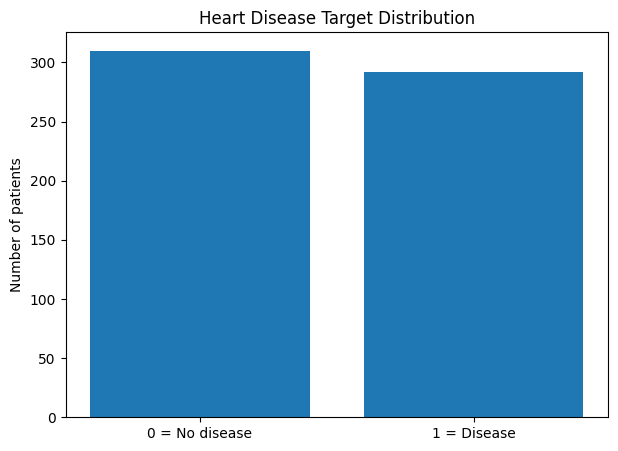

,count
target,
0,310
1,292


,proportion
target,
0,0.51495
1,0.48505


In [12]:
counts = df_clean["target"].value_counts().sort_index()

plt.figure(figsize=(7,5))
plt.bar(["0 = No disease", "1 = Disease"], counts.values)
plt.ylabel("Number of patients")
plt.title("Heart Disease Target Distribution")
plt.show()

display(df_clean["target"].value_counts())
display(df_clean["target"].value_counts(normalize=True))


In [13]:
display(df_clean.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,602.0,54.473422,9.039576,29.0,48.0,55.0,61.00,77.0
sex,602.0,0.684385,0.465147,0.0,0.0,1.0,1.00,1.0
cp,602.0,1.511628,1.166945,0.0,0.0,2.0,3.00,3.0
trestbps,602.0,131.637874,17.509164,94.0,120.0,130.0,140.00,200.0
chol,602.0,248.450166,51.552293,126.0,212.0,244.0,276.75,564.0
fbs,602.0,0.151163,0.358505,0.0,0.0,0.0,0.00,1.0
restecg,602.0,0.744186,0.812347,0.0,0.0,1.0,1.00,2.0
thalachh,602.0,149.270764,23.122436,71.0,132.0,152.5,165.75,202.0
exang,602.0,0.337209,0.473150,0.0,0.0,0.0,1.00,1.0
oldpeak,602.0,1.073256,1.156289,0.0,0.0,0.8,1.80,6.2


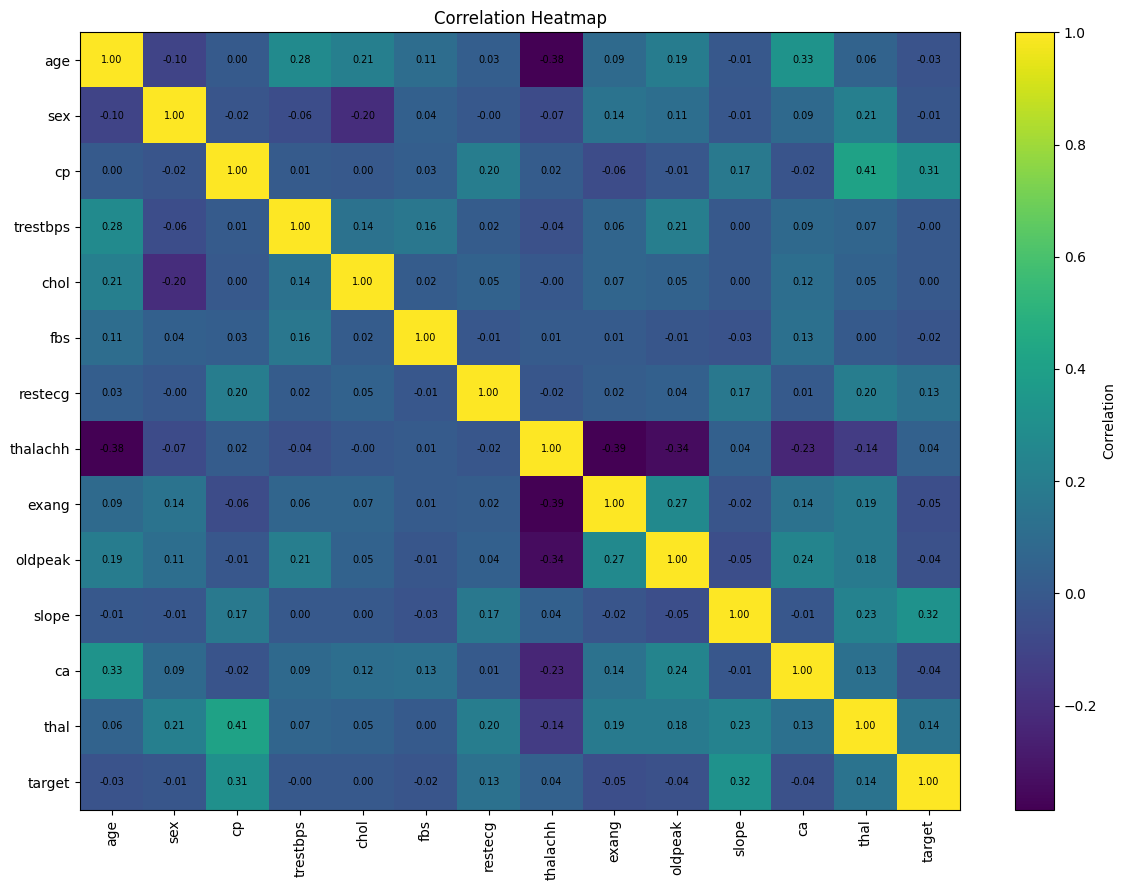

,correlation_with_target
target,1.000000
slope,0.318541
cp,0.312440
thal,0.141963
restecg,0.129800
thalachh,0.044157
chol,0.002746
trestbps,-0.000619
sex,-0.013163
fbs,-0.019852


In [14]:
corr = df_clean.corr(numeric_only=True)

plt.figure(figsize=(12,9))
plt.imshow(corr.values, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}",
                 ha="center", va="center", fontsize=7)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

display(corr["target"].sort_values(ascending=False).to_frame("correlation_with_target"))


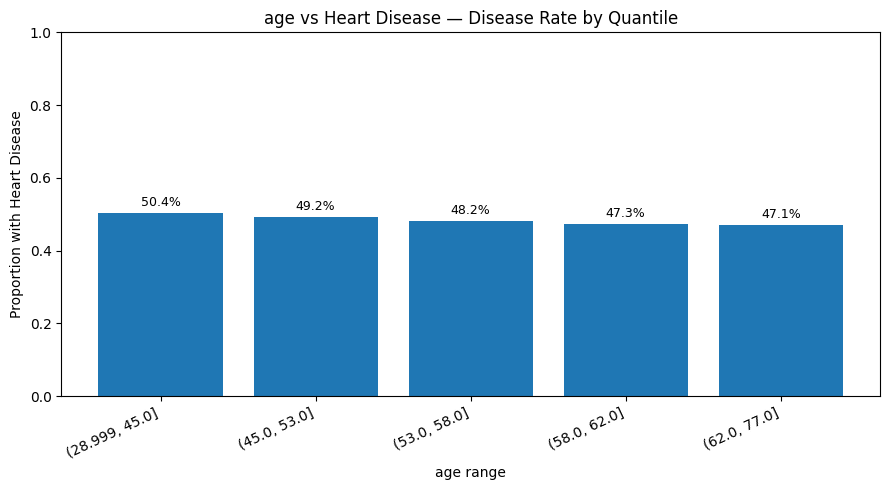

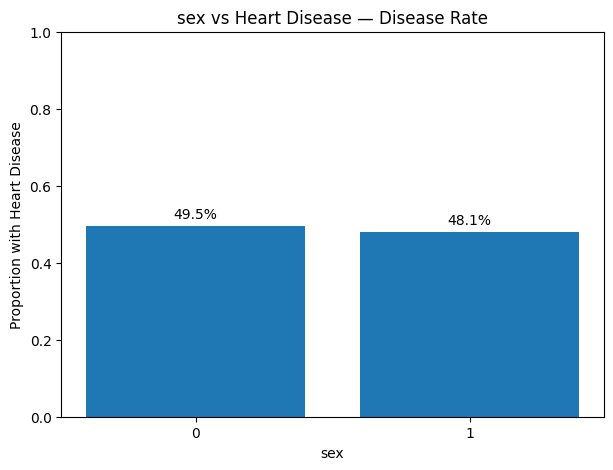

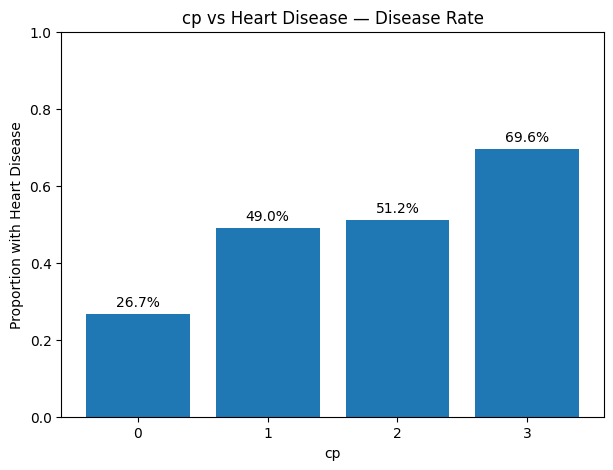

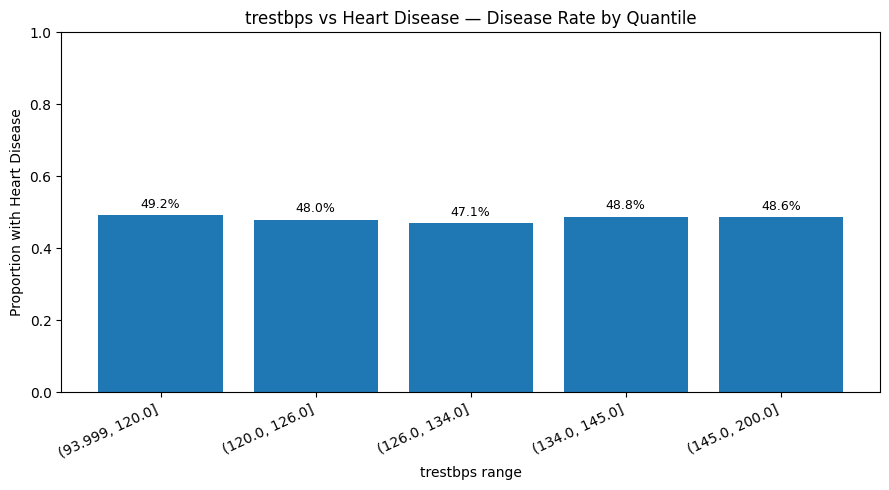

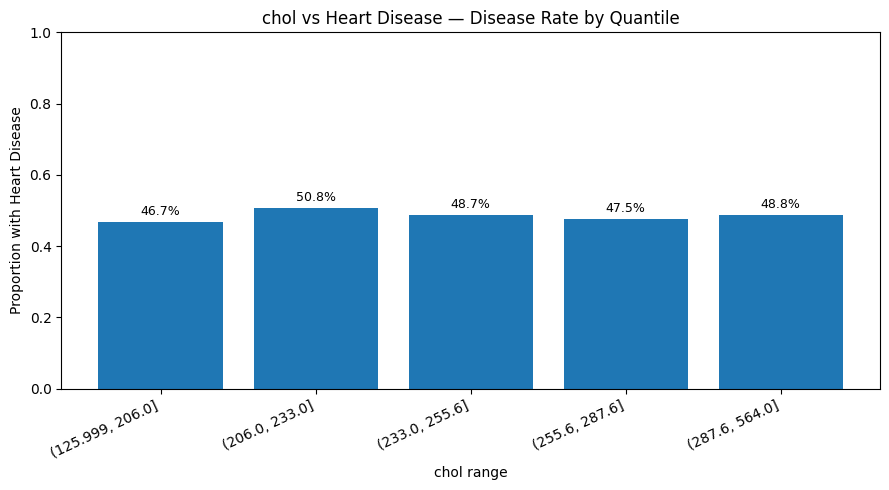

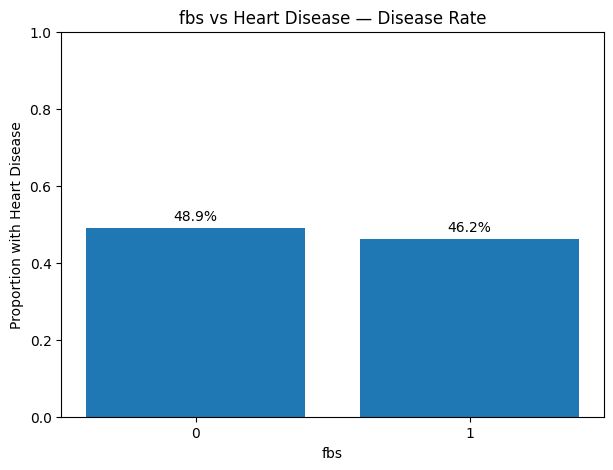

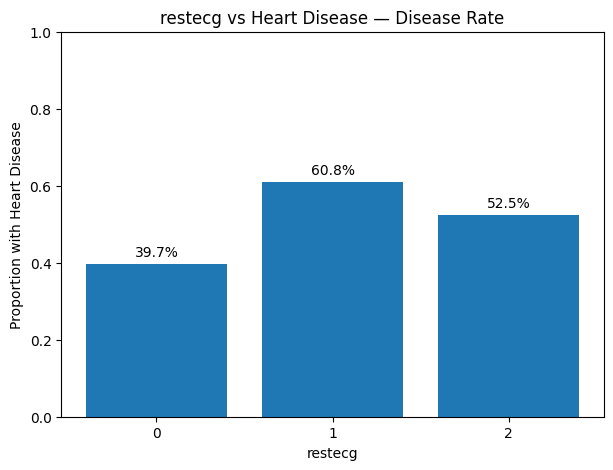

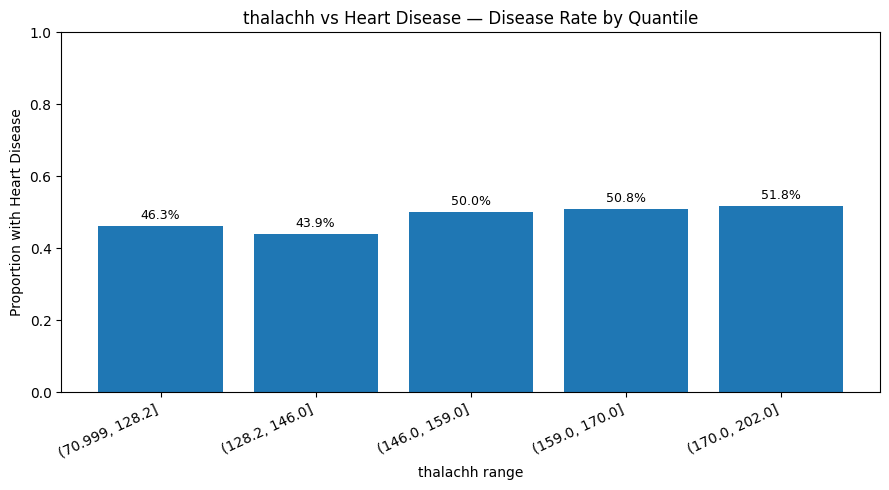

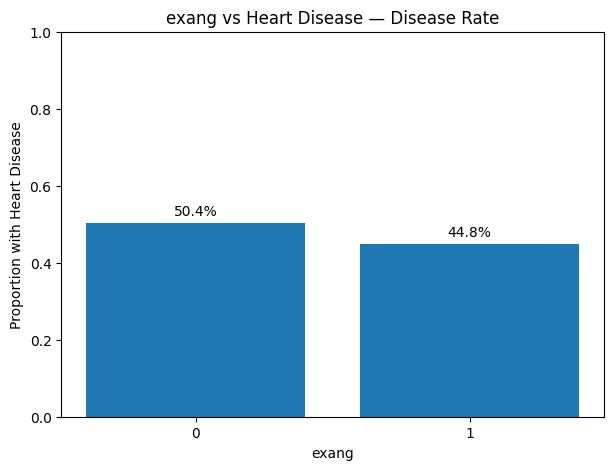

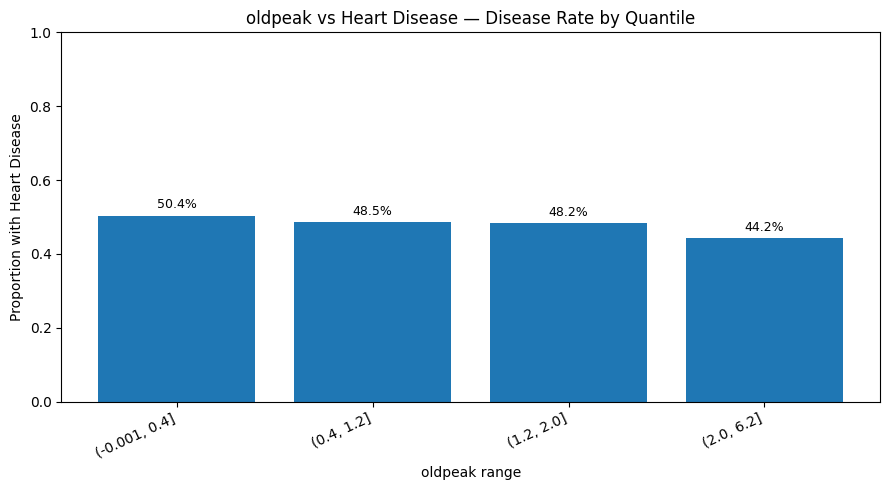

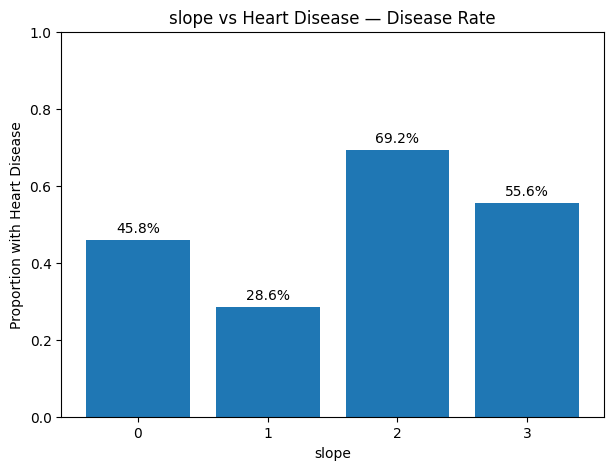

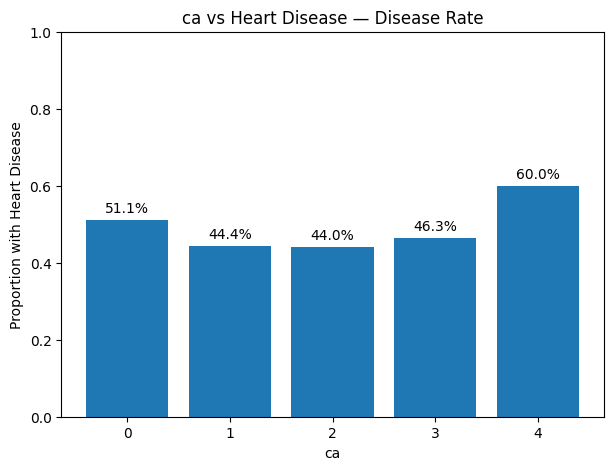

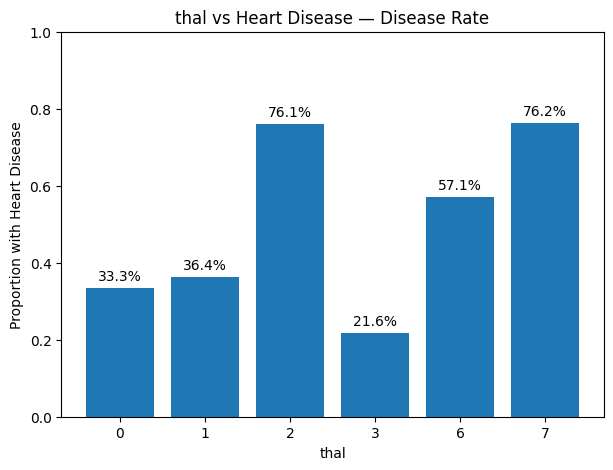

In [15]:
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
numeric_features = [
    c for c in df_clean.columns
    if c not in categorical_features + ["target"]
]

for col in df_clean.columns:
    if col == "target":
        continue

    if col in categorical_features:
        grouped = df_clean.groupby(col)["target"].agg(["mean","count"]).reset_index()
        x = np.arange(len(grouped))

        plt.figure(figsize=(7,5))
        plt.bar(x, grouped["mean"])
        plt.xticks(x, grouped[col].astype(str))
        plt.ylim(0,1)
        plt.xlabel(col)
        plt.ylabel("Proportion with Heart Disease")
        plt.title(f"{col} vs Heart Disease — Disease Rate")

        for i, v in enumerate(grouped["mean"]):
            plt.text(i, v + 0.02, f"{v:.1%}", ha="center")

        plt.show()

    else:
        temp = df_clean[[col,"target"]].copy()
        temp["bin"] = pd.qcut(temp[col], q=5, duplicates="drop")
        grouped = temp.groupby("bin", observed=True)["target"].mean()

        x = np.arange(len(grouped))

        plt.figure(figsize=(9,5))
        plt.bar(x, grouped.values)
        plt.xticks(x, [str(v) for v in grouped.index],
                   rotation=25, ha="right")
        plt.ylim(0,1)
        plt.xlabel(f"{col} range")
        plt.ylabel("Proportion with Heart Disease")
        plt.title(f"{col} vs Heart Disease — Disease Rate by Quantile")

        for i, v in enumerate(grouped.values):
            plt.text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=9)

        plt.tight_layout()
        plt.show()


In [16]:
X = df_clean.drop(columns="target")
y = df_clean["target"]

print("X:", X.shape)
print("y:", y.shape)


X: (602, 13)
y: (602,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train rows:", len(X_train))
print("Test rows :", len(X_test))


Train rows: 481
Test rows : 121


In [18]:
categorical_features = [
    "sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"
]

numeric_features = [
    "age", "trestbps", "chol", "thalachh", "oldpeak"
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


In [19]:
models = {
    "Linear Regression": LinearRegression(),

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "SVM": SVC(
        probability=True,
        random_state=RANDOM_STATE
    ),

    "KNN": KNeighborsClassifier(n_neighbors=7)
}


In [20]:
results = []
trained_models = {}
predictions = {}
scores = {}

for name, estimator in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])

    pipe.fit(X_train, y_train)

    if name == "Linear Regression":
        y_score = pipe.predict(X_test)
        y_pred = (y_score >= 0.5).astype(int)

        mae = mean_absolute_error(y_test, y_score)
        rmse = np.sqrt(mean_squared_error(y_test, y_score))
        r2 = r2_score(y_test, y_score)

    else:
        y_score = pipe.predict_proba(X_test)[:, 1]
        y_pred = pipe.predict(X_test)

        mae = np.nan
        rmse = np.nan
        r2 = np.nan

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_score),
        "PR_AUC": average_precision_score(y_test, y_score),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    trained_models[name] = pipe
    predictions[name] = y_pred
    scores[name] = y_score

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
display(results_df)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MAE,RMSE,R2
3,Random Forest,0.834711,0.854545,0.796610,0.824561,0.919492,0.916439,NaN,NaN,NaN
5,KNN,0.801653,0.786885,0.813559,0.800000,0.880946,0.883629,NaN,NaN,NaN
4,SVM,0.793388,0.793103,0.779661,0.786325,0.871241,0.873379,NaN,NaN,NaN
2,Decision Tree,0.785124,0.779661,0.779661,0.779661,0.833516,0.774160,NaN,NaN,NaN
1,Logistic Regression,0.776860,0.775862,0.762712,0.769231,0.854839,0.816378,NaN,NaN,NaN
0,Linear Regression,0.768595,0.762712,0.762712,0.762712,0.846364,0.800232,0.307891,0.403714,0.347658



Linear Regression
                  precision    recall  f1-score   support

No Heart Disease       0.77      0.77      0.77        62
   Heart Disease       0.76      0.76      0.76        59

        accuracy                           0.77       121
       macro avg       0.77      0.77      0.77       121
    weighted avg       0.77      0.77      0.77       121


Logistic Regression
                  precision    recall  f1-score   support

No Heart Disease       0.78      0.79      0.78        62
   Heart Disease       0.78      0.76      0.77        59

        accuracy                           0.78       121
       macro avg       0.78      0.78      0.78       121
    weighted avg       0.78      0.78      0.78       121


Decision Tree
                  precision    recall  f1-score   support

No Heart Disease       0.79      0.79      0.79        62
   Heart Disease       0.78      0.78      0.78        59

        accuracy                           0.79       121
       ma

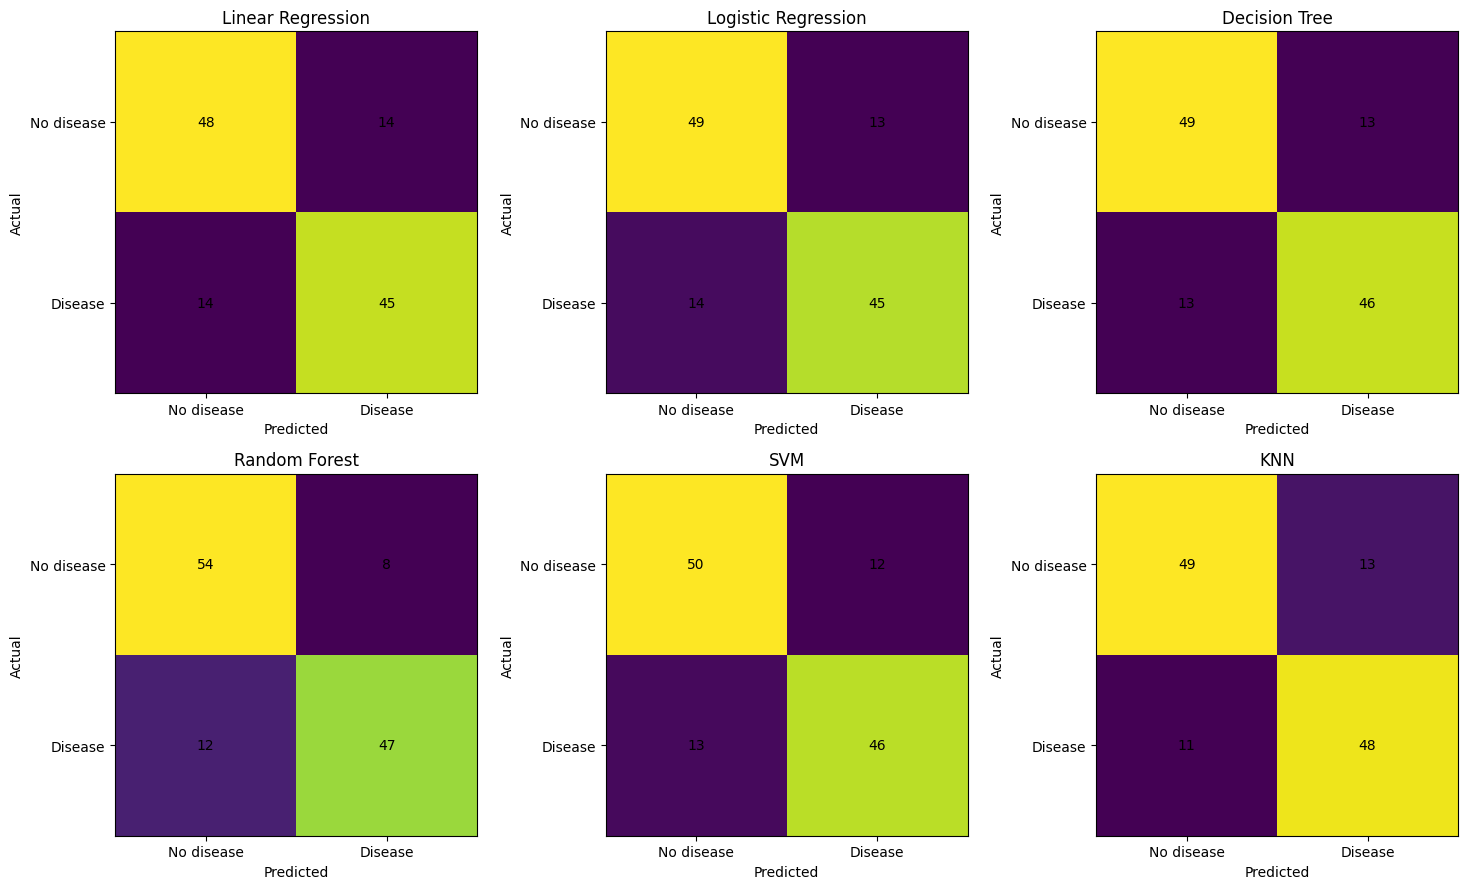

In [21]:
for name in models:
    print("\n" + "="*70)
    print(name)
    print("="*70)
    print(classification_report(
        y_test,
        predictions[name],
        target_names=["No Heart Disease", "Heart Disease"],
        zero_division=0
    ))

# Confusion matrix grid
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, predictions[name])
    ax.imshow(cm)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i,j], ha="center", va="center")

    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(["No disease","Disease"])
    ax.set_yticklabels(["No disease","Disease"])

plt.tight_layout()
plt.show()


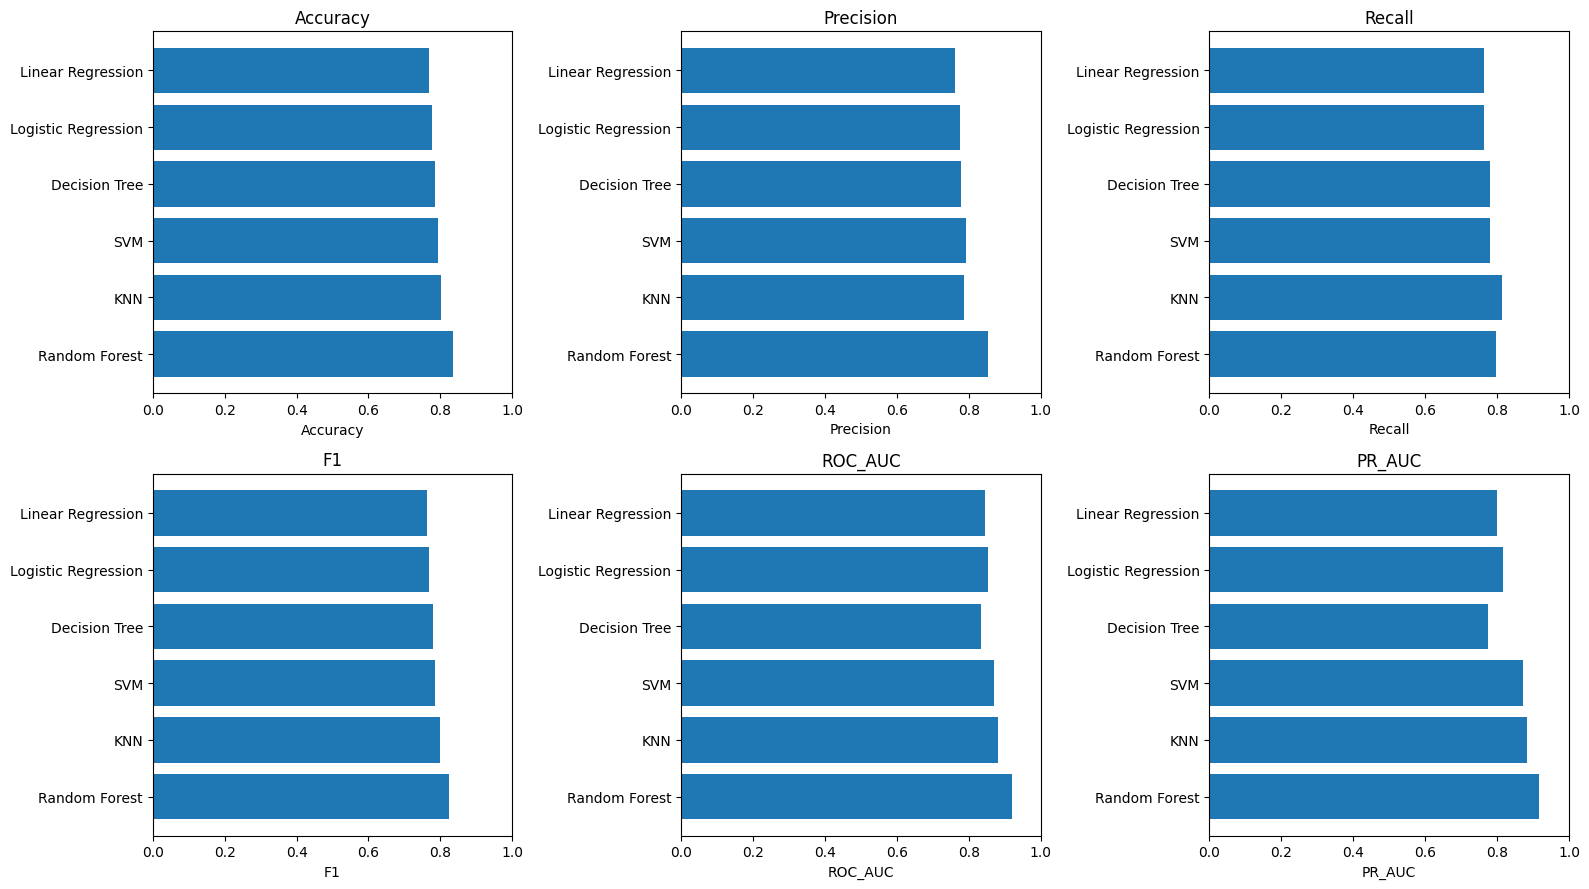

In [22]:
metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, metric in zip(axes, metric_cols):
    ax.barh(results_df["Model"], results_df[metric])
    ax.set_xlim(0,1)
    ax.set_title(metric)
    ax.set_xlabel(metric)

plt.tight_layout()
plt.show()


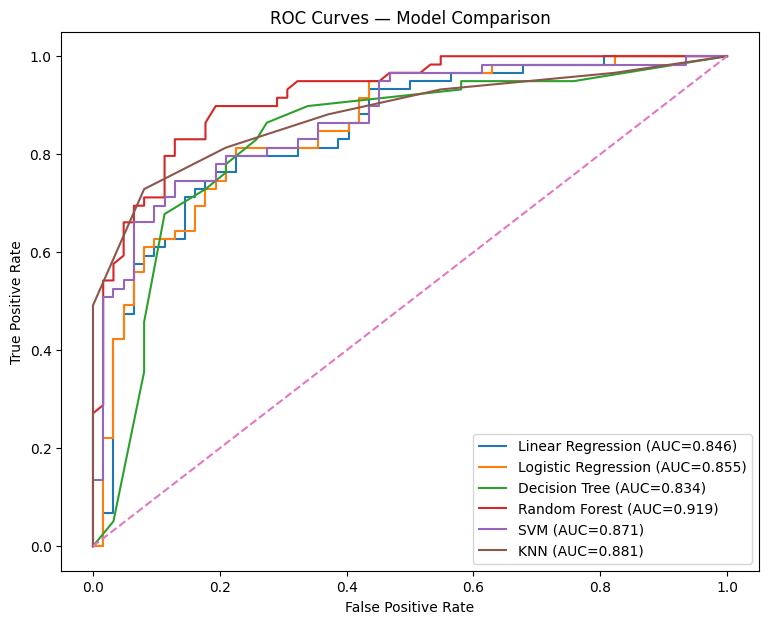

In [23]:
plt.figure(figsize=(9,7))

for name in models:
    fpr, tpr, _ = roc_curve(y_test, scores[name])
    auc = roc_auc_score(y_test, scores[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend()
plt.show()


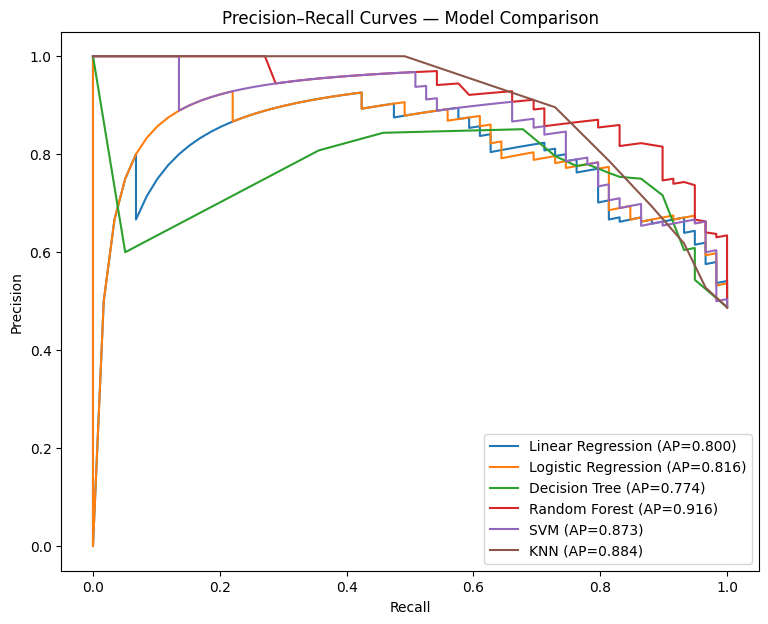

In [24]:
plt.figure(figsize=(9,7))

for name in models:
    precision, recall, _ = precision_recall_curve(y_test, scores[name])
    ap = average_precision_score(y_test, scores[name])
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves — Model Comparison")
plt.legend()
plt.show()


In [25]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_rows = []

for name, estimator in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])

    cv_scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    cv_rows.append({
        "Model": name,
        "CV ROC-AUC Mean": cv_scores.mean(),
        "CV ROC-AUC Std": cv_scores.std()
    })

cv_df = pd.DataFrame(cv_rows).sort_values(
    "CV ROC-AUC Mean",
    ascending=False
)

display(cv_df)


,Model,CV ROC-AUC Mean,CV ROC-AUC Std
3,Random Forest,0.881676,0.018397
4,SVM,0.849736,0.027156
1,Logistic Regression,0.849695,0.025735
5,KNN,0.815177,0.027515
2,Decision Tree,0.751387,0.036310
0,Linear Regression,NaN,NaN


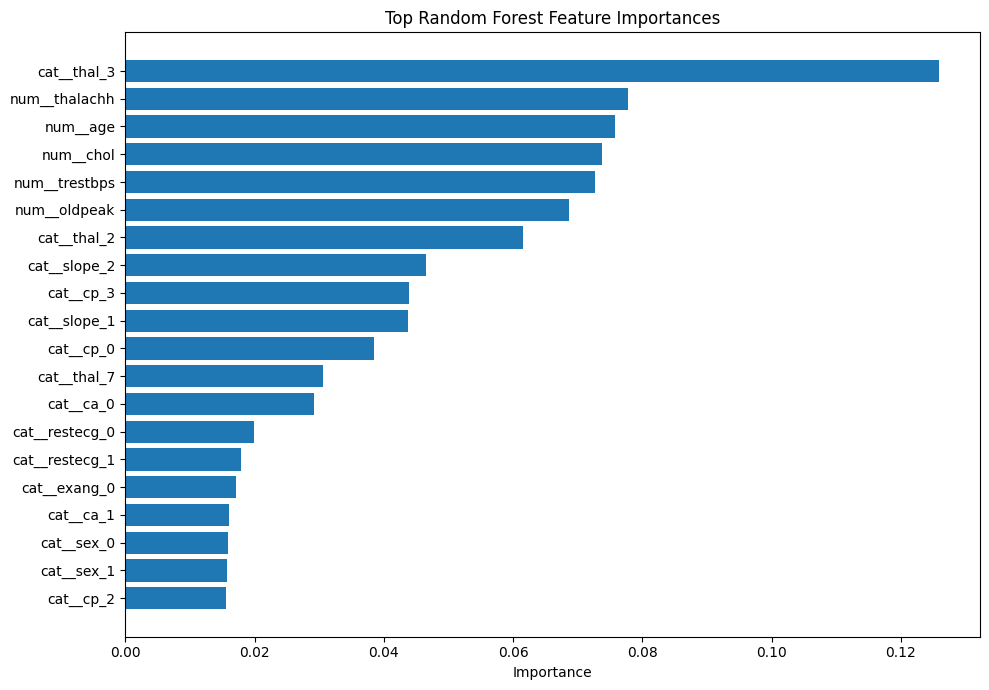

,Feature,Importance
30,cat__thal_3,0.125941
3,num__thalachh,0.077720
0,num__age,0.075722
2,num__chol,0.073736
1,num__trestbps,0.072617
4,num__oldpeak,0.068647
29,cat__thal_2,0.061515
20,cat__slope_2,0.046604
10,cat__cp_3,0.043964
19,cat__slope_1,0.043744


In [26]:
rf_pipe = trained_models["Random Forest"]

feature_names = rf_pipe.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipe.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
    .head(20)
)

plt.figure(figsize=(10,7))
plt.barh(
    importance_df["Feature"][::-1],
    importance_df["Importance"][::-1]
)
plt.xlabel("Importance")
plt.title("Top Random Forest Feature Importances")
plt.tight_layout()
plt.show()

display(importance_df)


In [27]:
print("Best model by F1:")
print(results_df.iloc[0]["Model"])

print("\nBest model by ROC-AUC:")
print(results_df.sort_values("ROC_AUC", ascending=False).iloc[0]["Model"])

print("\nTest-set comparison:")
display(results_df)

print("\nCross-validation comparison:")
display(cv_df)


Best model by F1:
Random Forest

Best model by ROC-AUC:
Random Forest

Test-set comparison:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MAE,RMSE,R2
3,Random Forest,0.834711,0.854545,0.796610,0.824561,0.919492,0.916439,NaN,NaN,NaN
5,KNN,0.801653,0.786885,0.813559,0.800000,0.880946,0.883629,NaN,NaN,NaN
4,SVM,0.793388,0.793103,0.779661,0.786325,0.871241,0.873379,NaN,NaN,NaN
2,Decision Tree,0.785124,0.779661,0.779661,0.779661,0.833516,0.774160,NaN,NaN,NaN
1,Logistic Regression,0.776860,0.775862,0.762712,0.769231,0.854839,0.816378,NaN,NaN,NaN
0,Linear Regression,0.768595,0.762712,0.762712,0.762712,0.846364,0.800232,0.307891,0.403714,0.347658



Cross-validation comparison:


,Model,CV ROC-AUC Mean,CV ROC-AUC Std
3,Random Forest,0.881676,0.018397
4,SVM,0.849736,0.027156
1,Logistic Regression,0.849695,0.025735
5,KNN,0.815177,0.027515
2,Decision Tree,0.751387,0.036310
0,Linear Regression,NaN,NaN


In [28]:
df_clean.to_csv("Heart_cleaned.csv", index=False)
results_df.to_csv("model_comparison_results.csv", index=False)
cv_df.to_csv("cross_validation_results.csv", index=False)

print("Saved successfully.")


Saved successfully.
